# Class Conditioning & Generation
This notebook covers:
1. Validating that class conditioning is working correctly in the model
2. Running the reverse diffusion loop to generate synthetic readmission patients
3. Generating at 50%, 100%, and 200% augmentation levels
4. Building augmented training sets for the evaluation stage
5. Sanity checking synthetic patients against real ones

## Setup & Imports

In [1]:
import torch
import pickle
import numpy as np
import pandas as pd
import os
import sys

# Make sure tabddpm_model.py and generate.py can be imported from this folder
sys.path.append(os.path.dirname(os.path.abspath('')))

from tabddpm_model import TabDDPMDenoiser, validate_class_conditioning
from generate import generate_patients

# File paths
CONFIG_PATH   = '../models/diffusion_config.pkl'
MODEL_PATH    = '../models/tabddpm_best.pt'
X_TRAIN_PATH  = '../data/processed/X_train.csv'
Y_TRAIN_PATH  = '../data/processed/y_train.csv'
SYNTHETIC_DIR = '../data/synthetic'

os.makedirs(SYNTHETIC_DIR, exist_ok=True)

## Load Config and Check Column Counts

Load the diffusion config, this tells us which columns are numeric, which are categorical, and what the noise schedule looks like

Expected: 9 numeric, 33 categorical, 42 total

In [2]:
with open(CONFIG_PATH, 'rb') as f:
    cfg = pickle.load(f)

print('Config keys:', list(cfg.keys()))
print(f"Numeric columns : {len(cfg['numeric_indices'])}")
print(f"Categorical cols: {len(cfg['cat_indices'])}")
print(f"Total features  : {len(cfg['numeric_indices']) + len(cfg['cat_indices'])}")

Config keys: ['T', 'betas', 'alphas', 'alpha_bars', 'all_columns', 'numeric_columns', 'categorical_columns', 'numeric_indices', 'cat_indices', 'cat_num_classes', 'num_classes_per_cat']
Numeric columns : 9
Categorical cols: 33
Total features  : 42



## Instantiate the Model

Build the model architecture using the column info from the config. This sets up the network structure but doesn't load any trained weights yet

Expected: ~1,728,503 parameters

In [3]:
model = TabDDPMDenoiser(
    num_numeric       = len(cfg['numeric_indices']),
    cat_cardinalities = cfg['cat_num_classes'],
    numeric_indices   = cfg['numeric_indices'],
    cat_indices       = cfg['cat_indices'],
)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 1,728,503


## Load Trained Weights

Load the trained weights into the model

The checkpoint contains epoch, loss, and model_state - we only need model_state

model.eval() sets it to evaluation mode — disables dropout

In [ ]:
checkpoint = torch.load(MODEL_PATH, map_location='cpu')
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Best epoch: {checkpoint['epoch']}, Best loss: {checkpoint['loss']:.4f}")

TabDDPMDenoiser(
  (cat_embeddings): ModuleList(
    (0): Embedding(5, 3)
    (1): Embedding(2, 2)
    (2): Embedding(9, 5)
    (3): Embedding(29, 15)
    (4): Embedding(26, 13)
    (5-7): 3 x Embedding(9, 5)
    (8-14): 7 x Embedding(4, 2)
    (15): Embedding(2, 2)
    (16-17): 2 x Embedding(4, 2)
    (18): Embedding(2, 2)
    (19-22): 4 x Embedding(4, 2)
    (23): Embedding(2, 2)
    (24): Embedding(3, 2)
    (25-26): 2 x Embedding(4, 2)
    (27-32): 6 x Embedding(2, 2)
  )
  (input_proj): Sequential(
    (0): Linear(in_features=112, out_features=256, bias=True)
    (1): SiLU()
  )
  (time_sin): SinusoidalTimestepEmbedding()
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (class_emb): Embedding(2, 64)
  (class_proj): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): SiLU()
  )
  (blocks): ModuleList(
    (0-3): 4 x ResidualBlock(


## Generate Synthetic Patients at 3 Augmentation Levels

Generate at three augmentation levels to find the optimal amount of synthetic data

50% = half the minority class size, 100% = same size, 200% = double

target_class = 1 means we only generate readmitted patients

In [5]:
y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
minority_count = (y_train == 1).sum()
print(f'Minority class (readmitted <30) in training set: {minority_count:,}')

for pct in [50, 100, 200]:
    n = int(minority_count * pct / 100)
    print(f'\n {pct}% augmentation: generating {n:,} synthetic patients')

    synthetic = generate_patients(
        model_path   = MODEL_PATH,
        config_path  = CONFIG_PATH,
        X_train_path = X_TRAIN_PATH,
        y_train_path = Y_TRAIN_PATH,
        n_samples    = n,
        target_class = 1,
    )

    out_path = os.path.join(SYNTHETIC_DIR, f'synthetic_{pct}pct.csv')
    synthetic.to_csv(out_path, index=False)

Minority class (readmitted <30) in training set: 9,051

 50% augmentation: generating 4,525 synthetic patients
Model loaded. Numeric cols: 9, Categorical cols: 33

Generating 4525 synthetic patients (class=1)


/Users/simishrivastava/tabddpm-hospital-readmission-prediction/notebook/generate.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  betas      = torch.tensor(cfg['betas'],      dtype=torch.float32, device=device)
/Users/simishrivastava/tabddpm-hospital-readmission-prediction/notebook/generate.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alphas     = torch.tensor(cfg['alphas'],     dtype=torch.float32, device=device)
/Users/simishrivastava/tabddpm-hospital-readmission-prediction/notebook/generate.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tens

Sampled 4525 categorical rows from 9051 real readmitted patients.

Synthetic.shape = (4525, 42)

 100% augmentation: generating 9,051 synthetic patients
Model loaded. Numeric cols: 9, Categorical cols: 33

Generating 9051 synthetic patients (class=1)


/Users/simishrivastava/tabddpm-hospital-readmission-prediction/notebook/generate.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  betas      = torch.tensor(cfg['betas'],      dtype=torch.float32, device=device)
/Users/simishrivastava/tabddpm-hospital-readmission-prediction/notebook/generate.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alphas     = torch.tensor(cfg['alphas'],     dtype=torch.float32, device=device)
/Users/simishrivastava/tabddpm-hospital-readmission-prediction/notebook/generate.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tens

Sampled 9051 categorical rows from 9051 real readmitted patients.

Synthetic.shape = (9051, 42)

 200% augmentation: generating 18,102 synthetic patients
Model loaded. Numeric cols: 9, Categorical cols: 33

Generating 18102 synthetic patients (class=1)


/Users/simishrivastava/tabddpm-hospital-readmission-prediction/notebook/generate.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  betas      = torch.tensor(cfg['betas'],      dtype=torch.float32, device=device)
/Users/simishrivastava/tabddpm-hospital-readmission-prediction/notebook/generate.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alphas     = torch.tensor(cfg['alphas'],     dtype=torch.float32, device=device)
/Users/simishrivastava/tabddpm-hospital-readmission-prediction/notebook/generate.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tens

Sampled 18102 categorical rows from 9051 real readmitted patients.

Synthetic.shape = (18102, 42)


## Build Augmented Training Sets

Combine real training data with the synthetic minority patients. All synthetic patients are class 1 (readmitted) — add their labels accordingly

In [6]:
X_train = pd.read_csv(X_TRAIN_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()

print(f'Original training set: {len(X_train):,} rows')
print(f'Minority class: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')
print()

for pct in [50, 100, 200]:
    synthetic = pd.read_csv(os.path.join(SYNTHETIC_DIR, f'synthetic_{pct}pct.csv'))
    n = len(synthetic)

    # Add synthetic patients to the real training set
    X_aug = pd.concat([X_train, synthetic], ignore_index=True)
    y_aug = pd.concat([y_train, pd.Series([1] * n)], ignore_index=True)

    X_aug.to_csv(os.path.join(SYNTHETIC_DIR, f'X_train_aug_{pct}pct.csv'), index=False)
    y_aug.to_csv(os.path.join(SYNTHETIC_DIR, f'y_train_aug_{pct}pct.csv'), index=False)

    total_minority = (y_train == 1).sum() + n
    print(f'{pct}%: {len(X_aug):,} total rows | '
          f'{total_minority:,} minority ({total_minority/len(X_aug)*100:.1f}%)')


Original training set: 79,472 rows
Minority class: 9,051 (11.4%)

50%: 83,997 total rows | 13,576 minority (16.2%)
100%: 88,523 total rows | 18,102 minority (20.4%)
200%: 97,574 total rows | 27,153 minority (27.8%)


## Sanity Check: One Synthetic Patient vs. Real Ones

Compare one synthetic patient against the average real readmitted patient

Values won't be identical — we're comparing one patient to a mean of 9000+, but they should be in a similar range — this is a quick plausibility check

In [7]:
synthetic_50 = pd.read_csv(os.path.join(SYNTHETIC_DIR, 'synthetic_50pct.csv'))
X_train      = pd.read_csv(X_TRAIN_PATH)
y_train      = pd.read_csv(Y_TRAIN_PATH).squeeze()
real_minority = X_train[y_train == 1]

comparison = pd.DataFrame({
    'synthetic_patient'     : synthetic_50.iloc[0].round(3),
    'real_mean (readmitted)': real_minority.mean().round(3),
    'real_std (readmitted)' : real_minority.std().round(3),
})

print('Synthetic patient vs. real readmitted patients\n')
print(comparison.to_string())

Synthetic patient vs. real readmitted patients

                          synthetic_patient  real_mean (readmitted)  real_std (readmitted)
race                                  2.000                   1.657                  0.849
gender                                1.000                   0.455                  0.498
age                                   0.635                   0.067                  0.992
admission_type_id                     1.000                   1.981                  1.428
discharge_disposition_id              6.000                   4.435                  6.060
admission_source_id                   7.000                   5.835                  3.988
time_in_hospital                     -1.047                   0.133                  1.022
num_lab_procedures                   -2.048                   0.067                  0.989
num_procedures                       -0.779                  -0.031                  0.961
num_medications                      -0.73

## Distribution Plots (Real vs. Synthetic)

Pick 4 interpretable numeric columns to compare visually

Top row = real patients (blue), bottom row = synthetic (red)

If the shapes look similar, the model is generating realistic patients

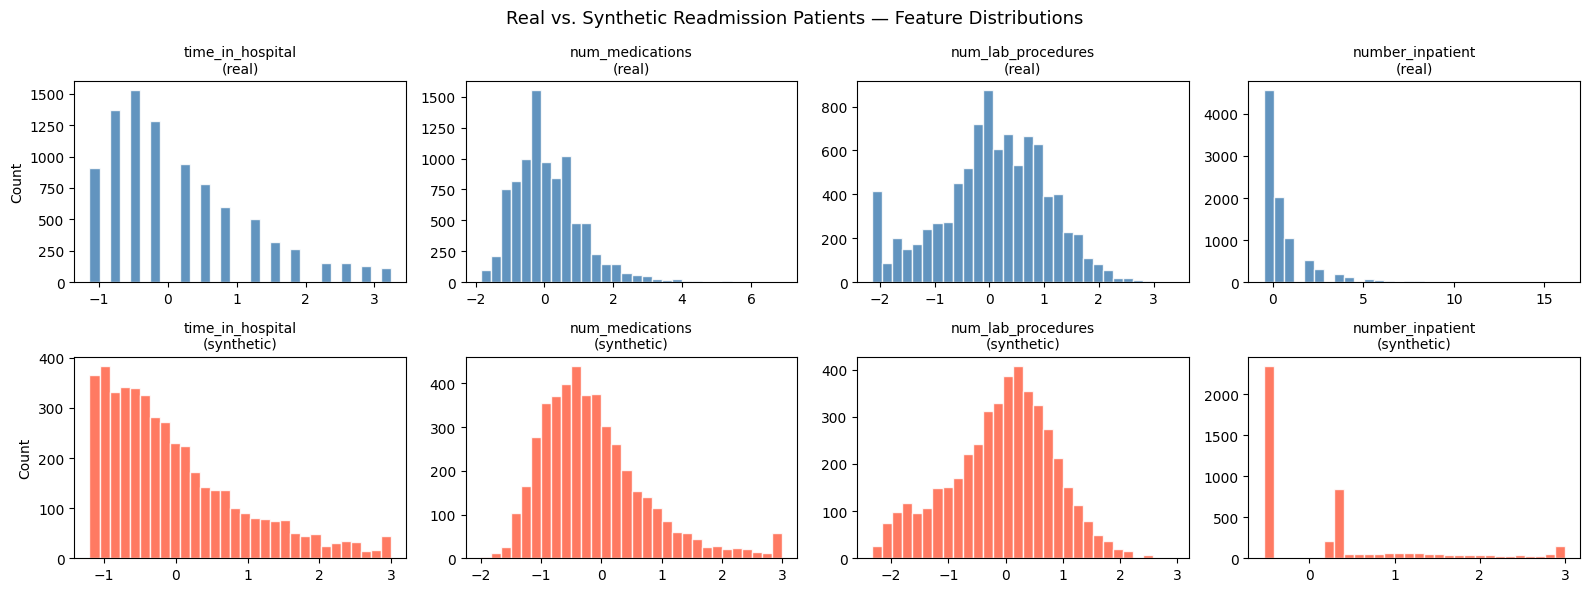

In [8]:
import matplotlib.pyplot as plt

synthetic_50  = pd.read_csv(os.path.join(SYNTHETIC_DIR, 'synthetic_50pct.csv'))
X_train       = pd.read_csv(X_TRAIN_PATH)
y_train       = pd.read_csv(Y_TRAIN_PATH).squeeze()
real_minority = X_train[y_train == 1]

# The 4 most interpretable numeric columns
PLOT_COLS = ['time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_inpatient']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Real vs. Synthetic Readmission Patients — Feature Distributions', fontsize=13)

for i, col in enumerate(PLOT_COLS):
    if col not in real_minority.columns:
        continue

    axes[0, i].hist(real_minority[col].dropna(), bins=30, color='steelblue',
                    edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col}\n(real)', fontsize=10)
    axes[0, i].set_ylabel('Count' if i == 0 else '')

    axes[1, i].hist(synthetic_50[col].dropna(), bins=30, color='tomato',
                    edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'{col}\n(synthetic)', fontsize=10)
    axes[1, i].set_ylabel('Count' if i == 0 else '')

plt.tight_layout()
plt.savefig('../results/figures/real_vs_synthetic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## Jensen-Shannon Divergence numbers

Jensen-Shannon divergence measures how similar two distributions are 0.0 = identical, 1.0 = completely different

Anything below 0.2 is generally considered a good match

Adding small epsilon (1e-10) to avoid log(0) errors

In [9]:
from scipy.spatial.distance import jensenshannon
import numpy as np

synthetic_50  = pd.read_csv(os.path.join(SYNTHETIC_DIR, 'synthetic_50pct.csv'))
X_train       = pd.read_csv(X_TRAIN_PATH)
y_train       = pd.read_csv(Y_TRAIN_PATH).squeeze()
real_minority = X_train[y_train == 1]

PLOT_COLS = ['time_in_hospital', 'num_medications', 'num_lab_procedures', 'number_inpatient']

print("Jensen-Shannon Divergence (lower = more similar, max = 1.0)\n")
for col in PLOT_COLS:
    bins = np.linspace(
        min(real_minority[col].min(), synthetic_50[col].min()),
        max(real_minority[col].max(), synthetic_50[col].max()),
        50
    )
    real_hist, _ = np.histogram(real_minority[col].dropna(), bins=bins, density=True)
    syn_hist,  _ = np.histogram(synthetic_50[col].dropna(),  bins=bins, density=True)
    js = jensenshannon(real_hist + 1e-10, syn_hist + 1e-10)
    print(f"  {col}: {js:.4f}")

Jensen-Shannon Divergence (lower = more similar, max = 1.0)

  time_in_hospital: 0.6007
  num_medications: 0.1800
  num_lab_procedures: 0.1468
  number_inpatient: 0.3005


## t-SNE plot

t-SNE reduces all features to 2 dimensions so we can plot them. If real and synthetic patients overlap, the generated data is realistic

Sampling 500 from each to keep it fast — t-SNE is slow on large datasets


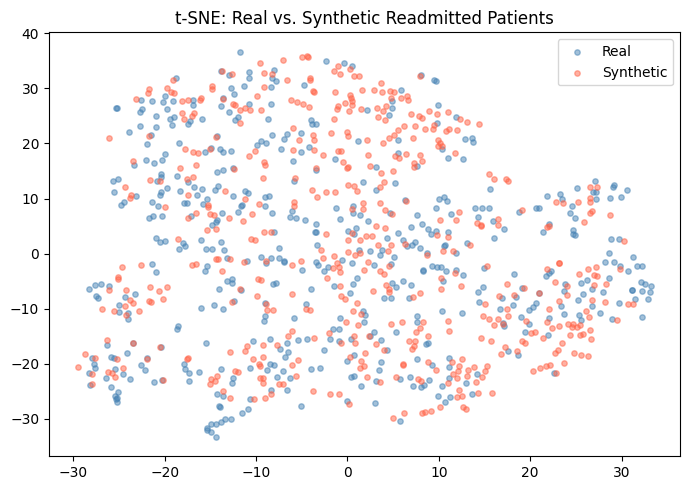

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

numeric_cols = [X_train.columns[i] for i in cfg['numeric_indices']]
real_sample = real_minority[numeric_cols].dropna().sample(500, random_state=42)
syn_sample  = synthetic_50[numeric_cols].dropna().sample(500, random_state=42)

combined = pd.concat([real_sample, syn_sample], ignore_index=True)
labels   = ['Real'] * 500 + ['Synthetic'] * 500

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(combined)

plt.figure(figsize=(7, 5))
for label, color in [('Real', 'steelblue'), ('Synthetic', 'tomato')]:
    mask = [l == label for l in labels]
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=label, color=color, alpha=0.5, s=15)

plt.title('t-SNE: Real vs. Synthetic Readmitted Patients')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/tsne_real_vs_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()